# Homodyne SFG Processing — Walkthrough

This notebook walks through a complete **homodyne** SFG processing pipeline,
step by step, using the pure-Python API in `sfg_app2.processing` (no GUI
required).

A homodyne measurement needs four raw files:
- **signal** — the sample spectrum
- **background** — dark/background counts for the signal
- **reference** — a reference material (e.g. quartz) used to normalize out
  the laser's spectral shape
- **reference background** — dark/background counts for the reference

Pipeline: **despike → average frames → subtract background → normalize →
convert wavelength to wavenumber (upconversion)**.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from sfg_app2.processing.data_file import DataFile
from sfg_app2.processing.matcher import MatchedSet
from sfg_app2.processing.baseline import subtract_background
from sfg_app2.processing.normalization import normalize
from sfg_app2.processing.pipeline import PipelineConfig, process_matched

DATA_DIR = Path("data/pharos/2026_07_17")

## 1. Load the raw data

Each file is loaded as a `DataFile`, which reads the raw CSV (handling both
long- and wide-format instrument exports automatically) and exposes its
frames. Every spectrum object in this pipeline shares a `.plot()` method,
used throughout this notebook.

signal: 2 frames, 1024 points/frame


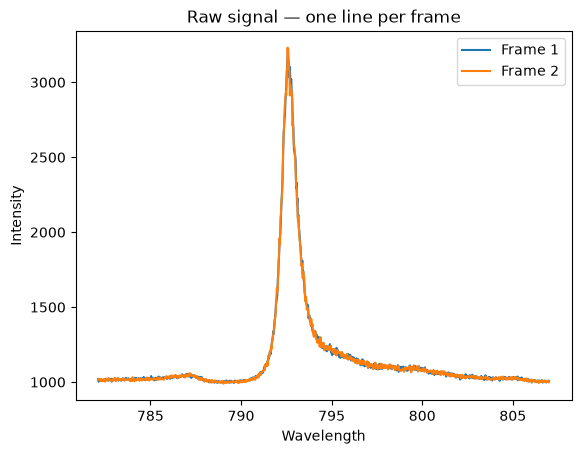

In [2]:
signal = DataFile(DATA_DIR / "DMSO_5kHz_ssp_3.45um_60s_1444_2026Jul17_homodyne.csv")
background = DataFile(DATA_DIR / "DMSO_5kHz_ssp_3.45um_60s_1444_2026Jul17_homodyne_bg.csv")
reference = DataFile(DATA_DIR / "quartz_5kHz_ssp_3.45um_10s_1601_2026Jul17_homodyne.csv")
reference_bg = DataFile(DATA_DIR / "quartz_5kHz_ssp_3.45um_10s_1601_2026Jul17_homodyne_bg.csv")

print(f"signal: {signal.n_frames} frames, {len(signal.frame(1))} points/frame")

fig, ax = plt.subplots()
signal.plot(ax=ax)
ax.set_title("Raw signal — one line per frame")
ax.legend()
plt.show()

## 2. Remove cosmic ray spikes (despike)

`remove_cosmic_rays(window, threshold_factor)` detects outliers with a
rolling-median filter and linearly interpolates over them. `window` is the
number of points in the rolling window; `threshold_factor` controls how far
(in median-absolute-deviations) a point must be from its local median to be
flagged as a spike — smaller values flag more points as spikes.

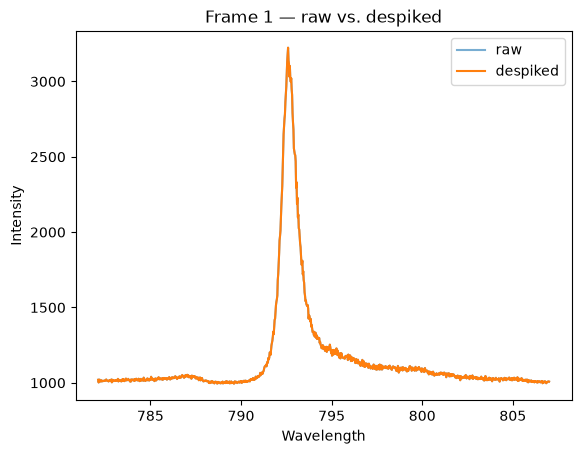

In [3]:
signal_despiked = signal.remove_cosmic_rays(window=20, threshold_factor=500.0)

fig, ax = plt.subplots()
signal.plot(ax=ax, frame_id=1, label="raw", alpha=0.6)
signal_despiked.plot(ax=ax, frame_id=1, label="despiked")
ax.set_title("Frame 1 — raw vs. despiked")
ax.legend()
plt.show()

## 3. Average frames

`average_spectrum()` collapses all frames into a single averaged spectrum
(also computing a per-point standard deviation across frames).

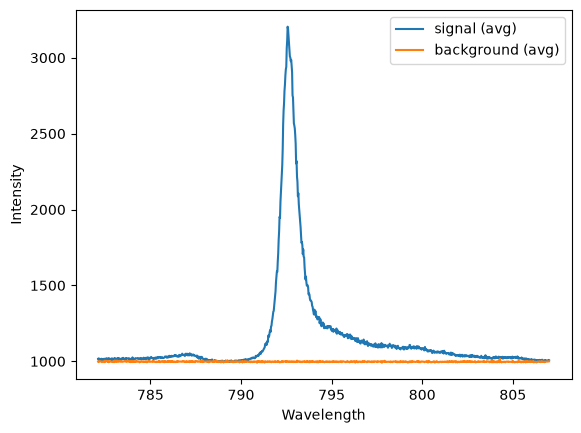

In [4]:
signal_avg = signal_despiked.average_spectrum()
background_avg = background.remove_cosmic_rays(window=20, threshold_factor=500.0).average_spectrum()

fig, ax = plt.subplots()
signal_avg.plot(ax=ax, label="signal (avg)")
background_avg.plot(ax=ax, label="background (avg)")
ax.legend()
plt.show()

## 4. Subtract the background — with an optional offset

`subtract_background(signal, background, offset=...)` subtracts the
background from the signal. `offset` is an example **tunable option**: it
accepts `None` (no offset), a constant, a list of polynomial coefficients
(applied via `np.polyval` against wavelength), or a callable
`f(wavelength) -> offset_array` — useful for compensating a background that
drifted slightly between the signal and background acquisitions.

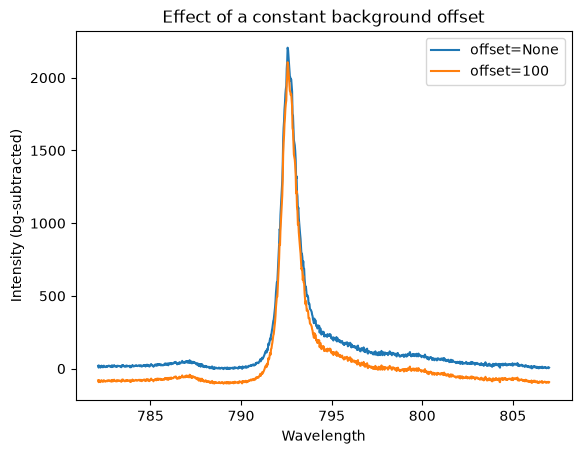

In [7]:
no_offset = subtract_background(signal_avg, background_avg)
with_offset = subtract_background(signal_avg, background_avg, offset=100)

fig, ax = plt.subplots()
no_offset.plot(ax=ax, label="offset=None")
with_offset.plot(ax=ax, label="offset=100")
ax.set_ylabel("Intensity (bg-subtracted)")
ax.set_title("Effect of a constant background offset")
ax.legend()
plt.show()

## 5. Process the reference and normalize

The reference goes through the same despike → average → background-subtract
steps, then `normalize(sample, reference)` divides the sample by the
reference (point by point in wavelength) to remove the laser's spectral
shape.

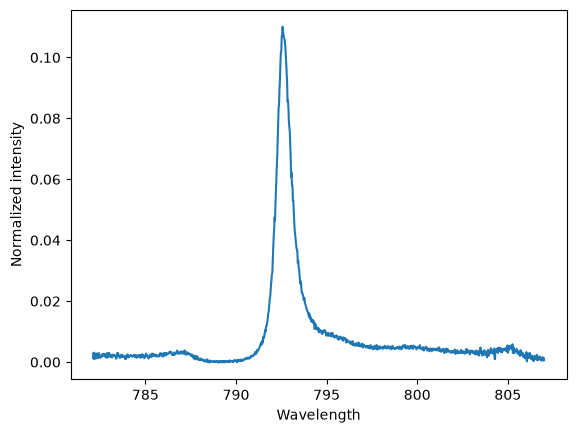

In [8]:
reference_avg = reference.remove_cosmic_rays(window=20, threshold_factor=500.0).average_spectrum()
reference_bg_avg = reference_bg.remove_cosmic_rays(window=20, threshold_factor=500.0).average_spectrum()
reference_corrected = subtract_background(reference_avg, reference_bg_avg)

normalized = normalize(no_offset, reference_corrected)

fig, ax = plt.subplots()
normalized.plot(ax=ax)
ax.set_ylabel("Normalized intensity")
plt.show()

## 6. Convert wavelength to wavenumber (upconversion)

`upconvert_to_wavenumber(upconversion_wavelength)` adds a `Wavenumber`
column, computed from the known upconversion beam wavelength (here ~1030 nm,
this system's fiber-laser upconversion wavelength).

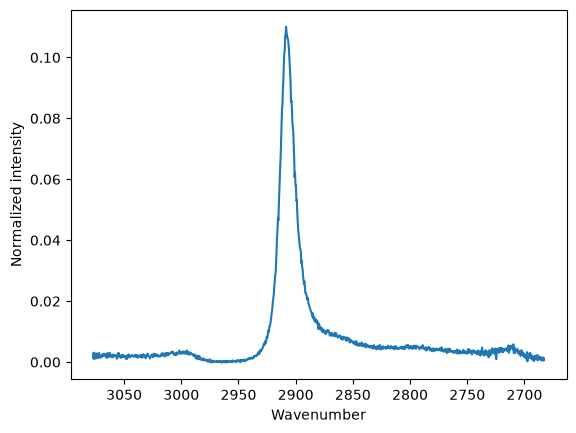

In [9]:
upconverted = normalized.upconvert_to_wavenumber(1030.0)

fig, ax = plt.subplots()
upconverted.plot(ax=ax, x="Wavenumber")
ax.set_ylabel("Normalized intensity")
ax.invert_xaxis()
plt.show()

## Putting it all together

Everything above is exactly what `process_matched` does in one call, driven
by a `PipelineConfig`. This is the pattern to reuse when looping over many
files with `process_batch` — see `sfg_app2.processing.pipeline`.

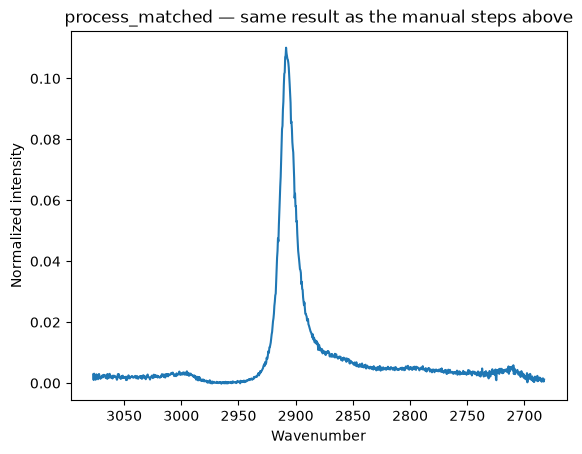

In [10]:
matched = MatchedSet(
    signal=signal,
    background=background,
    reference=reference,
    reference_background=reference_bg,
)

config = PipelineConfig(
    despike_window=20,
    despike_threshold=500.0,
    bg_offset=0,
    upconversion_wavelength=1030.0,
)

result = process_matched(matched, config)

fig, ax = plt.subplots()
result.plot(ax=ax, x="Wavenumber")
ax.set_ylabel("Normalized intensity")
ax.invert_xaxis()
ax.set_title("process_matched — same result as the manual steps above")
plt.show()

## Next steps

- `process_batch(matched_sets, default_config, per_file_configs=None)` runs
  this same pipeline over a list of `MatchedSet`s in one call, with optional
  per-file config overrides.
- The desktop app's **Load/Match** tab can auto-match many files into
  `MatchedSet`s for you (rather than constructing them by hand as above),
  and its **Process/Review** tab lets you tune these same parameters
  interactively with a live preview.
